In [1]:
import tensorflow as tf
import torchvision.models as models
import torch.nn as nn
import torchvision.transforms as transforms
from PIL import Image
import requests
from io import BytesIO
import torch
import torch.optim as optim
import torch.nn.utils.prune as prune
from torch.utils.data import DataLoader, Subset
from torchvision import datasets
import torchvision

import copy
import math
from typing import List, Tuple
import time


import cv2
import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
def get_train_transform(transform_size=224):
  train_transform = transforms.Compose([
      transforms.Resize((transform_size, transform_size)),
      transforms.RandomHorizontalFlip(),
      transforms.ToTensor(),
      transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
  ])
  return train_transform

def get_test_transform(transform_size):
  test_transform = transforms.Compose([
      transforms.Resize((transform_size, transform_size)),
      transforms.ToTensor(),
      transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
  ])
  return test_transform


In [5]:
def get_train_val_split(dataset='10', val_ratio=0.1, seed=42):
  if dataset == '10':
    full_train_for_indices = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=None)
  else:
    full_train_for_indices = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=None)

  num_train = len(full_train_for_indices)
  num_val = int(val_ratio * num_train)
  num_train_split = num_train - num_val

  generator = torch.Generator().manual_seed(seed)
  permuted_indices = torch.randperm(num_train, generator=generator).tolist()

  train_indices = permuted_indices[:num_train_split]
  val_indices = permuted_indices[num_train_split:]

  return train_indices, val_indices


In [6]:
# from torchvision.datasets.vision import data
def load_dataset(dataset='10', val_ratio=0.1, seed=42, batch_size=64):
  train_transform = get_train_transform(transform_size=224)
  test_transform = get_test_transform(transform_size=224)

  if dataset == '10':
    train_indices, val_indices = get_train_val_split(dataset=dataset, val_ratio=val_ratio, seed=seed)

    trainset_full = torchvision.datasets.CIFAR10(root='./data', train=True, download=False, transform=train_transform)
    valset_full = datasets.CIFAR10(root="./data", train=True, download=False, transform=test_transform)

    trainset = Subset(trainset_full, train_indices)
    valset = Subset(valset_full, val_indices)

    trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    valloader = torch.utils.data.DataLoader(valset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    # Download and load test dataset
    testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)
    testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

    print('CIFAR-10 dataset downloaded and loaded successfully.')

  elif dataset == '100':
    train_indices, val_indices = get_train_val_split(dataset=dataset, val_ratio=val_ratio, seed=seed)

    trainset_full = torchvision.datasets.CIFAR100(root='./data', train=True, download=False, transform=train_transform)
    valset_full = datasets.CIFAR100(root="./data", train=True, download=False, transform=test_transform)

    trainset = Subset(trainset_full, train_indices)
    valset = Subset(valset_full, val_indices)

    trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    valloader = torch.utils.data.DataLoader(valset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    # Download and load test dataset
    testset = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=test_transform)
    testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    classes = ('beaver', 'dolphin', 'otter', 'seal', 'whale', 'aquarium fish', 'flatfish', 'ray', 'shark', 'trout', 'orchids', 'poppies', 'roses', 'sunflowers', 'tulips', 'bottles', 'bowls', 'cans', 'cups', 'plates', 'apples', 'mushrooms', 'oranges', 'pears', 'sweet peppers', 'clock', 'computer keyboard', 'lamp', 'telephone', 'television', 'bed', 'chair', 'couch', 'table', 'wardrobe', 'bee', 'beetle', 'butterfly', 'caterpillar', 'cockroach', 'bear', 'leopard', 'lion', 'tiger', 'wolf', 'bridge', 'castle', 'house', 'road', 'skyscraper', 'cloud', 'forest', 'mountain', 'plain', 'sea', 'camel', 'cattle', 'chimpanzee', 'elephant', 'kangaroo', 'fox', 'porcupine', 'possum', 'raccoon', 'skunk', 'crab', 'lobster', 'snail', 'spider', 'worm', 'baby', 'boy', 'girl', 'man', 'woman', 'crocodile', 'dinosaur', 'lizard', 'snake', 'turtle', 'hamster', 'mouse', 'rabbit', 'shrew', 'squirrel', 'maple', 'oak', 'palm', 'pine', 'willow', 'bicycle', 'bus', 'motorcycle', 'pickup truck', 'train', 'lawn-mower', 'rocket', 'streetcar', 'tank', 'tractor')
    print('CIFAR-100 dataset downloaded and loaded successfully.')

  return trainset, trainloader, testset, testloader, valset, valloader, classes


In [7]:
def customize_model(model, num_classes):
  model.classifier[6] = nn.Linear(4096, num_classes)
  return model


In [8]:
def get_model(num_classes, path=''):
  model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
  model = customize_model(model, num_classes)
  if path != '':
    print(f'Loading model from path {path}')
    model.load_state_dict(torch.load(path, map_location=device))
  model = model.to(device)
  return model

In [9]:
def get_normalized_bounds(mean, std, device):
    """
    Compute the minimum and maximum valid values in normalized space.

    What this function does:
    - Assumes the original image pixels must stay in [0, 1]
    - Converts that valid pixel range into normalized-space bounds
    - Returns tensors shaped for broadcasting over a batch of images
    """
    mean = mean.to(device).view(1, 3, 1, 1)
    std = std.to(device).view(1, 3, 1, 1)

    clamp_min = (0.0 - mean) / std
    clamp_max = (1.0 - mean) / std
    return clamp_min, clamp_max

In [10]:
def fgsm_attack_normalized(image, epsilon, data_grad, std):
    """
    Apply FGSM to normalized images while interpreting epsilon in pixel space.

    What this function does:
    - Takes the gradient w.r.t. the normalized input image
    - Converts the pixel-space epsilon into channel-wise normalized epsilon
    - Adds an FGSM perturbation in normalized space
    - Returns the perturbed normalized image

    Parameters:
    - image: normalized input batch
    - epsilon: perturbation size in raw pixel space, e.g. 8/255
    - data_grad: gradient of loss w.r.t. image
    - std: channel standard deviations used in normalization
    """
    std = std.view(1, 3, 1, 1).to(image.device)
    epsilon_normalized = epsilon / std

    perturbed_image = image + epsilon_normalized * data_grad.sign()
    return perturbed_image

In [11]:

def generate_fgsm_examples(model, testloader, epsilon, device, CIFAR_MEAN, CIFAR_STD):
    """
    Generate FGSM adversarial examples for the test set.

    What this function does:
    - Runs the model on clean test images
    - Computes gradients of loss w.r.t. the input images
    - Creates FGSM adversarial examples using epsilon defined in pixel space
    - Clamps the perturbed images to valid normalized bounds
    - Evaluates the model on both clean and adversarial images
    - Stores results for later analysis or visualization

    Returns:
    - adv_examples: adversarial image batches
    - clean_examples: original image batches
    - labels_list: true labels
    - clean_preds_list: predictions on clean images
    - adv_preds_list: predictions on adversarial images
    - clean_acc: clean accuracy
    - adv_acc: adversarial accuracy
    """
    model.eval()
    criterion = nn.CrossEntropyLoss()

    mean = CIFAR_MEAN.to(device)
    std = CIFAR_STD.to(device)
    clamp_min, clamp_max = get_normalized_bounds(mean, std, device)

    correct_clean = 0
    correct_adv = 0
    total = 0

    batch = 0
    examples_10 = [] # 10: 1 = correct clean pred, 0 = incorrect adv pred
    examples_01 = []
    examples_000 = [] # 000: 0 = incorrect clean pred, 0 = incorrect adv pred, 0 = clean != adv
    examples_001 = [] # 000: 0 = incorrect clean pred, 0 = incorrect adv pred, 1 = clean == adv
    examples_11 = []

    examples_10_count = 0
    examples_01_count = 0
    examples_000_count = 0
    examples_001_count = 0
    examples_11_count = 0


    for images, labels in testloader:

        images = images.to(device)
        labels = labels.to(device)

        images.requires_grad = True

        # Forward pass on clean images
        outputs = model(images)
        loss = criterion(outputs, labels)

        _, clean_preds = torch.max(outputs, 1)
        correct_clean_this_batch = (clean_preds == labels).sum().item()
        correct_clean += correct_clean_this_batch

        model.zero_grad()
        loss.backward()

        data_grad = images.grad.detach()

        # Create adversarial images in normalized space,
        # but with epsilon interpreted in raw pixel space
        adv_images = fgsm_attack_normalized(images, epsilon, data_grad, std)

        # Keep adversarial images within valid normalized image range
        adv_images = torch.max(torch.min(adv_images, clamp_max), clamp_min)
        adv_images = adv_images.detach()

        # Forward pass on adversarial images
        adv_outputs = model(adv_images)
        _, adv_preds = torch.max(adv_outputs, 1)
        correct_adv_this_batch = (adv_preds == labels).sum().item()
        correct_adv += correct_adv_this_batch

        total += labels.size(0)

        # clean_examples.append(images.detach().cpu())
        # adv_examples.append(adv_images.cpu())
        # labels_list.append(labels.detach().cpu())
        # clean_preds_list.append(clean_preds.detach().cpu())
        # adv_preds_list.append(adv_preds.detach().cpu())

        examples_10_mask = (clean_preds == labels) & (adv_preds != labels)
        examples_10_indices = examples_10_mask.nonzero(as_tuple=True)[0]
        examples_10_count += len(examples_10_indices)
        examples_10_indices = examples_10_indices[:1]
        if len(examples_10) == 0:
          for idx in examples_10_indices:
              examples_10.append({
                  "clean_image": images[idx].detach().cpu(),
                  "adv_image": adv_images[idx].detach().cpu(),
                  "label": labels[idx].item(),
                  "clean_pred": clean_preds[idx].item(),
                  "adv_pred": adv_preds[idx].item(),
              })

        examples_01_mask = (clean_preds != labels) & (adv_preds == labels)
        examples_01_indices = examples_01_mask.nonzero(as_tuple=True)[0]
        examples_01_count += len(examples_01_indices)
        examples_01_indices = examples_01_indices[:1]
        if len(examples_01) == 0:
          for idx in examples_01_indices:
            examples_01.append({
                "clean_image": images[idx].detach().cpu(),
                "adv_image": adv_images[idx].detach().cpu(),
                "label": labels[idx].item(),
                "clean_pred": clean_preds[idx].item(),
                "adv_pred": adv_preds[idx].item(),
            })

        examples_000_mask = (clean_preds != labels) & (adv_preds != labels) & (clean_preds != adv_preds)
        examples_000_indices = examples_000_mask.nonzero(as_tuple=True)[0]
        examples_000_count += len(examples_000_indices)
        examples_000_indices = examples_000_indices[:1]
        if len(examples_000) == 0:
          for idx in examples_000_indices:
              examples_000.append({
                  "clean_image": images[idx].detach().cpu(),
                  "adv_image": adv_images[idx].detach().cpu(),
                  "label": labels[idx].item(),
                  "clean_pred": clean_preds[idx].item(),
                  "adv_pred": adv_preds[idx].item(),
              })

        examples_001_mask = (clean_preds != labels) & (adv_preds != labels) & (clean_preds == adv_preds)
        examples_001_indices = examples_001_mask.nonzero(as_tuple=True)[0]
        examples_001_count += len(examples_001_indices)
        examples_001_indices = examples_001_indices[:1]
        if len(examples_001) == 0:
          for idx in examples_001_indices:
              examples_001.append({
                  "clean_image": images[idx].detach().cpu(),
                  "adv_image": adv_images[idx].detach().cpu(),
                  "label": labels[idx].item(),
                  "clean_pred": clean_preds[idx].item(),
                  "adv_pred": adv_preds[idx].item(),
              })

        examples_11_mask = (clean_preds == labels) & (adv_preds == labels)
        examples_11_indices = examples_11_mask.nonzero(as_tuple=True)[0]
        examples_11_count += len(examples_11_indices)
        examples_11_indices = examples_11_indices[:1]
        if len(examples_11) == 0:
          for idx in examples_11_indices:
              examples_11.append({
                  "clean_image": images[idx].detach().cpu(),
                  "adv_image": adv_images[idx].detach().cpu(),
                  "label": labels[idx].item(),
                  "clean_pred": clean_preds[idx].item(),
                  "adv_pred": adv_preds[idx].item(),
              })


        # print(f"batch {batch}\tcorrect clean {correct_clean_this_batch} correct adv {correct_adv_this_batch} total {labels.size(0)}")
        if batch % 20 == 0:
          print(f'Batch {batch} done')
        batch += 1

    clean_acc = correct_clean / total
    adv_acc = correct_adv / total

    return (
        examples_10, examples_01, examples_000, examples_001, examples_11, examples_10_count, examples_01_count, examples_000_count, examples_001_count, examples_11_count, clean_acc, adv_acc
    )

In [12]:
def plot_clean_adv_pair(example, mean, std):
    """
    Plot one saved clean/adversarial pair side by side.

    What this function does:
    - Takes one dictionary from saved_examples
    - Unnormalizes the clean and adversarial images
    - Plots them side by side
    - Shows true label, clean prediction, and adversarial prediction
    """
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)

    clean_img = example["clean_image"] * std + mean
    adv_img = example["adv_image"] * std + mean

    clean_img = clean_img.clamp(0, 1).permute(1, 2, 0).numpy()
    adv_img = adv_img.clamp(0, 1).permute(1, 2, 0).numpy()

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    axes[0].imshow(clean_img)
    axes[0].set_title(f"Clean\nTrue: {example['label']}\nPred: {example['clean_pred']}")
    axes[0].axis("off")

    axes[1].imshow(adv_img)
    axes[1].set_title(f"Adversarial\nTrue: {example['label']}\nPred: {example['adv_pred']}")
    axes[1].axis("off")

    plt.tight_layout()
    return plt

In [13]:
# CIFAR test normalization used by your loader
CIFAR_MEAN = torch.tensor([0.485, 0.456, 0.406])
CIFAR_STD = torch.tensor([0.229, 0.224, 0.225])

In [14]:
load_path = '/content/drive/MyDrive/DLBA_Project/Models/vgg16_cifar10_two_stage_finetune.pth'
# save_path = '/content/drive/MyDrive/DLBA_Project/Models/vgg16_cifar10_prune_finetune.pth'
num_classes = 10
dataset = '10'

In [15]:
vgg16_model = get_model(num_classes=num_classes, path=load_path)
trainset, trainloader, testset, testloader, valset, valloader, classes = load_dataset(dataset = dataset)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 143MB/s]


Loading model from path /content/drive/MyDrive/DLBA_Project/Models/vgg16_cifar10_two_stage_finetune.pth


100%|██████████| 170M/170M [00:18<00:00, 9.06MB/s]


CIFAR-10 dataset downloaded and loaded successfully.


In [16]:
def measure_fgsm(model, testloader, epsilons, device, CIFAR_MEAN, CIFAR_STD):
  # epsilon = 8 / 255  # standard FGSM budget in pixel space

  for epsilon in epsilons:
    print(f'epsilon: {epsilon:.2f}')
    examples_10, examples_01, examples_000, examples_001, examples_11, examples_10_count, examples_01_count, examples_000_count, examples_001_count, examples_11_count, clean_acc, adv_acc = generate_fgsm_examples(
        model=vgg16_model,
        testloader=testloader,
        epsilon=epsilon,
        device=device,
        CIFAR_MEAN=CIFAR_MEAN,
        CIFAR_STD=CIFAR_STD
    )

    with open('/content/drive/MyDrive/DLBA_Project/Temporary/FGSM_finetuned_VGG.txt', 'a') as f:
      f.write("Epsilon: "+str(epsilon)+"\n")
      f.write("examples_10_count: "+str(examples_10_count)+"\n")
      f.write("examples_01_count: "+str(examples_01_count)+"\n")
      f.write("examples_000_count: "+str(examples_000_count)+"\n")
      f.write("examples_001_count: "+str(examples_001_count)+"\n")
      f.write("examples_11_count: "+str(examples_11_count)+'\n')
      f.write("Clean accuracy: "+str(clean_acc)+"\n")
      f.write("FGSM accuracy (epsilon="+str(epsilon)+"): "+str(adv_acc)+'\n\n\n\n')

    epsilon_cap = f"{epsilon:.2f}"
    for index,fig_list in enumerate([examples_10, examples_01, examples_000, examples_001, examples_11]):
      name_list = ['10', '01', '000', '001', '11']
      plt = plot_clean_adv_pair(fig_list[0], CIFAR_MEAN, CIFAR_STD)
      save_path = '/content/drive/MyDrive/DLBA_Project/Temporary/FGSM_finetuned_VGG_'+str(name_list[index])+"_"+str(epsilon_cap)+".jpg"
      plt.savefig(save_path,  format='jpg', dpi=300)



In [ ]:
epsilons = [2/255, 4/255, 16/255]
measure_fgsm(vgg16_model, testloader, epsilons, device, CIFAR_MEAN, CIFAR_STD)

epsilon: 0.01
Batch 0 done
Batch 20 done


/tmp/ipykernel_7364/4235522108.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mean = torch.tensor(mean).view(3, 1, 1)
/tmp/ipykernel_7364/4235522108.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  std = torch.tensor(std).view(3, 1, 1)


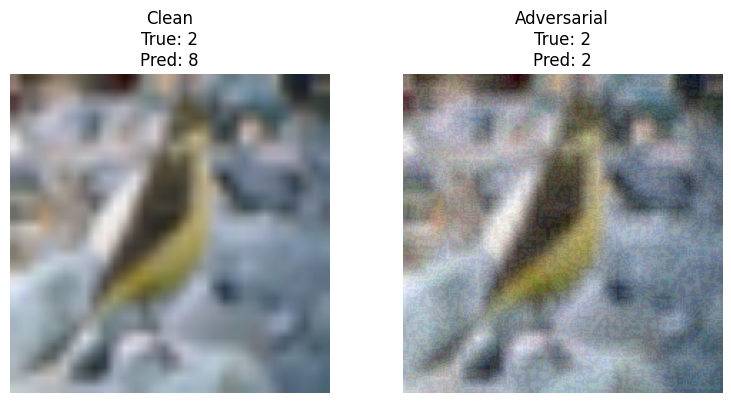

In [46]:
plot_clean_adv_pair(examples_01[2], CIFAR_MEAN, CIFAR_STD)




Key Exchange: Ch: 10.1-10.2-10.3
DDH Assumption: 8.3.1, 8.3.2
Chap 14:

In [17]:
index = 1
for images, labels in testloader:
  index += 1
print(index)

158
